In [19]:
!pip install kagglehub[pandas-datasets]
import kagglehub
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np



In [6]:
import pandas as pd
data = pd.read_csv(r'C:\allcodes\npkmodel\app\data_core.csv')

data.head()



,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26.0,52.0,38.0,Sandy,Maize,37,0,0,Urea
1,29.0,52.0,45.0,Loamy,Sugarcane,12,0,36,DAP
2,34.0,65.0,62.0,Black,Cotton,7,9,30,14-35-14
3,32.0,62.0,34.0,Red,Tobacco,22,0,20,28-28
4,28.0,54.0,46.0,Clayey,Paddy,35,0,0,Urea


In [7]:
features = ['Temparature', 'Humidity', 'Moisture', 'Soil Type']  # Match your column names
X = data[features]
y = data[['Nitrogen', 'Phosphorous', 'Potassium']]
X = pd.get_dummies(X)


In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# Load Data
data = pd.read_csv(r'C:\allcodes\npkmodel\app\data_core.csv')
features = ['Temparature', 'Humidity', 'Moisture', 'Soil Type']
X = data[features]
y = data[['Nitrogen', 'Phosphorous', 'Potassium']]
X = pd.get_dummies(X)  # Encode 'Soil Type'

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Save model
joblib.dump(model, 'npk_model.pkl')


['npk_model.pkl']

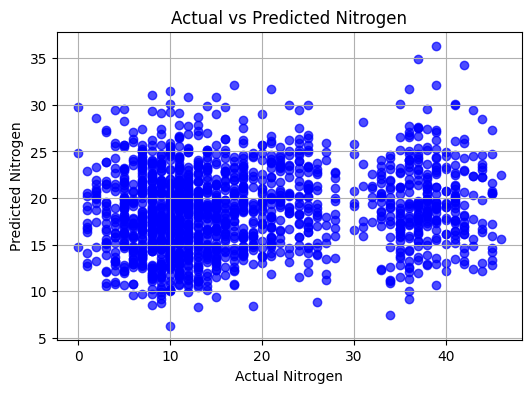

MAE (Nitrogen): 9.781659166666667
R2 (Nitrogen): -0.036368970688294144


In [11]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)

# For graphing Nitrogen as example:
plt.figure(figsize=(6,4))
plt.scatter(y_test['Nitrogen'], y_pred[:,0], color='b', alpha=0.7)
plt.xlabel('Actual Nitrogen')
plt.ylabel('Predicted Nitrogen')
plt.title('Actual vs Predicted Nitrogen')
plt.grid()
plt.show()

# Print evaluation metrics
print('MAE (Nitrogen):', mean_absolute_error(y_test['Nitrogen'], y_pred[:,0]))
print('R2 (Nitrogen):', r2_score(y_test['Nitrogen'], y_pred[:,0]))


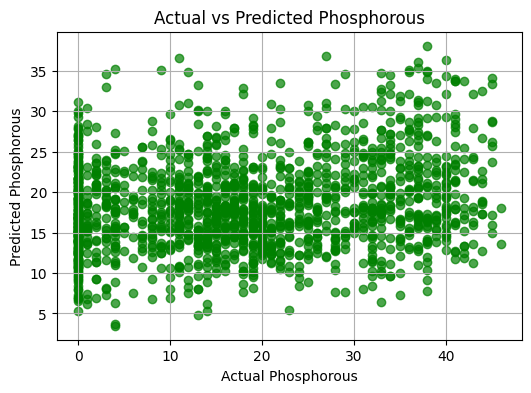

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.scatter(y_test['Phosphorous'], y_pred[:,1], color='g', alpha=0.7)
plt.xlabel('Actual Phosphorous')
plt.ylabel('Predicted Phosphorous')
plt.title('Actual vs Predicted Phosphorous')
plt.grid()
plt.show()


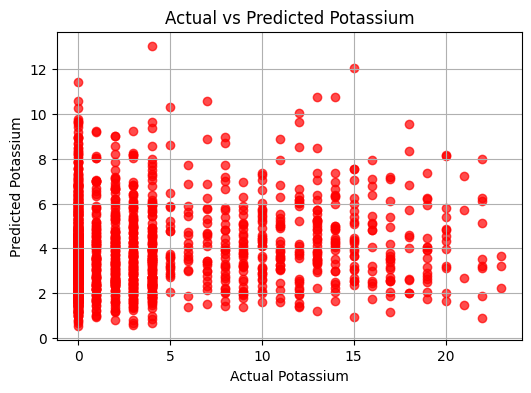

In [13]:
plt.figure(figsize=(6,4))
plt.scatter(y_test['Potassium'], y_pred[:,2], color='r', alpha=0.7)
plt.xlabel('Actual Potassium')
plt.ylabel('Predicted Potassium')
plt.title('Actual vs Predicted Potassium')
plt.grid()
plt.show()


In [14]:
from sklearn.metrics import mean_absolute_error, r2_score
print('MAE (Phosphorous):', mean_absolute_error(y_test['Phosphorous'], y_pred[:,1]))
print('R2 (Phosphorous):', r2_score(y_test['Phosphorous'], y_pred[:,1]))
print('MAE (Potassium):', mean_absolute_error(y_test['Potassium'], y_pred[:,2]))
print('R2 (Potassium):', r2_score(y_test['Potassium'], y_pred[:,2]))


MAE (Phosphorous): 10.937963020833333
R2 (Phosphorous): 0.004538906248924834
MAE (Potassium): 4.296914583333334
R2 (Potassium): -0.0451953621551866


In [15]:
sample = pd.DataFrame({
    'Temparature': [28],
    'Humidity': [60],
    'Moisture': [25],
    'Soil Type': ['Loamy']
})
sample = pd.get_dummies(sample)
sample = sample.reindex(columns=X.columns, fill_value=0)
pred_npk = model.predict(sample)
print('Predicted NPK:', pred_npk)


Predicted NPK: [[28.61 10.93  2.31]]
